# Height correction of Holomonitor data

Here, we compare the mean height of datasets with and without reference points, and determine the correction shift of datasets without reference points

In [53]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt


sys.path.append("scripts/utils/")
from file_operations import *
from SegmentedCells  import SegmentedCells
from Microscopes     import Holomonitor

In [54]:
_2DQPI = Holomonitor()

In [55]:
data_path = "../../../../hdd_data/silja/Monolayers/"

datasets_2D = [
    "MDCK_20240301_B1-4",
    "MDCK_20240301_B2-2",
    "MDCK_20240301_B2-6",
    "MDCK_20240317_B1-1",
    "MDCK_20240319_A1-9",
    "MDCK_20240319_A1-13",
    "MDCK_20240319_A1-16",
    "MDCK_20240319_A1-18",
    "MDCK_20240319_B1-11",
    "MDCK_20240516_A2-1", 
    "MDCK_20240516_A2-7",
    "MDCK_20240516_B1-9",
    "MDCK_20240516_B1-13",
    "MDCK_20240516_B1-22"
]


In [56]:
hmean_2D     = []
densities_2D = []

for dataset in datasets_2D:

    # load data
    config = json.load(open(f"configs/{dataset}.json"))
    stack  = load_stack(f"{data_path}height_fields/raw/{dataset}/", config, data_type="cells")
    cells  = SegmentedCells(f"{data_path}cell_features/raw/{dataset}_cells.p")

    # Compute mean height of monolayer
    hmean_tmp = np.array([np.mean(frame[frame > 0]) for frame in stack])

    hmean_2D.append( hmean_tmp )
    densities_2D.append(cells.density)


State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240301_B1-4_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240301_B2-2_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240301_B2-6_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240317_B1-1_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240319_A1-9_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240319_A1-13_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240319_A1-16_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240319_A1-18_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240319_B1-11_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK

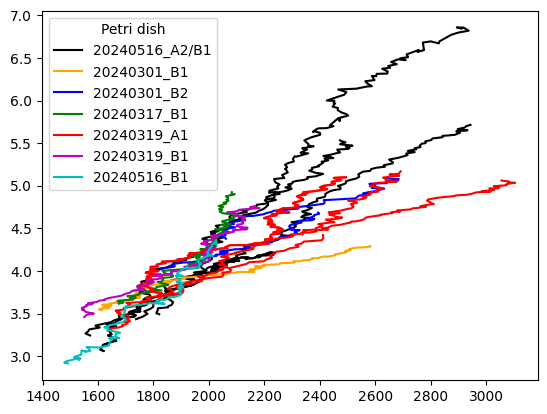

In [61]:
shift_1 = 0
shift_2 = 0
shift_3 = 0
shift_4 = 0
shift_5 = 0
shift_6 = 0

shift_1 = shift_4 = shift_5 = -.8
shift_2 = shift_3 = -1.5

plt.figure()

for h, rho in zip(hmean_2D[-4:],
                  densities_2D[-4:]):
    plt.plot(rho, h, '-', c='k')

plt.plot(densities_2D[-1], hmean_2D[-1],          'k',      label="20240516_A2/B1")
plt.plot(densities_2D[0],  hmean_2D[0] + shift_1, 'orange', label="20240301_B1")
plt.plot(densities_2D[1],  hmean_2D[1] + shift_2, 'b',      label="20240301_B2")
plt.plot(densities_2D[2],  hmean_2D[2] + shift_2, 'b')
plt.plot(densities_2D[3],  hmean_2D[3] + shift_3, 'g',      label="20240317_B1")
plt.plot(densities_2D[4],  hmean_2D[4] + shift_4, 'r',      label="20240319_A1")

for h, rho in zip(hmean_2D[4:-6],
                  densities_2D[4:-6]):
    plt.plot(rho, h+shift_4, '-', c='r')

plt.plot(densities_2D[-6], hmean_2D[-6] + shift_5, 'm', label="20240319_B1")
plt.plot(densities_2D[-5], hmean_2D[-5] + shift_6, 'c', label="20240516_B1")

plt.legend(title="Petri dish")